<a href="https://colab.research.google.com/github/pmolinari2910/Modelizado-de-IA/blob/main/Copia_de_Pracitica_Unidad_2_Algoritmos_Gen%C3%A9ticos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problema:**
## **Optimización del Cronograma de una Vivienda**
### **Contexto:**

Una empresa constructora tiene que realizar 10 tareas críticas para entregar una casa (cimientos, muros, techos, instalaciones, etc.). Cada tarea tiene una duración estimada y requiere un número específico de operarios.


### **El Desafío:**

La empresa solo cuenta con una cuadrilla de 10 operarios en total. Si intentamos hacer muchas tareas en paralelo, superaremos ese límite. Si las hacemos todas en serie, la obra tardará meses.

### **Consigna:**

Desarrollar un modelo de Algoritmo Genético (usando PyGAD o DEAP) que encuentre el orden secuencial de inicio de tareas que minimice el tiempo total de la obra (Makespan) sin exceder nunca el límite de 10 operarios por día.

## Pasos para la Resolución (Hoja de Ruta)

**Modelado de Datos:** Crear una estructura (diccionario o lista) que contenga las 10 tareas, su duración en días y la cantidad de operarios necesarios para cada una.

**Definición del Cromosoma:** Determinar cómo representar la solución. Una forma sencilla es un vector de números reales o enteros que represente el "orden de prioridad" o el "día de inicio" de cada tarea.

**Diseño de la Función de Aptitud (Fitness):** La función debe recibir el orden de las tareas y calcular el día final de obra.

***Importante:*** Si en algún día la suma de operarios de las tareas activas supera los 10, la función debe aplicar una penalización drástica (bajar el fitness) para que esa solución sea descartada por el algoritmo.

Como queremos minimizar el tiempo, el fitness podría ser

$$Fitness = \frac{1}{DíasTotales}$$.

**Configuración del GA:** Definir el tamaño de la población (ej. 50 individuos). Elegir el método de selección (Torneo o Ruleta).Establecer una probabilidad de mutación para evitar que todos los cronogramas se vuelvan iguales rápido.

**Ejecución y Monitoreo:** Correr el proceso evolutivo y observar la curva de fitness para verificar que el tiempo total de la obra disminuya con las generaciones.

**Análisis de Resultados:** Mostrar cuál es el orden de tareas óptimo encontrado y confirmar que el uso de operarios sea legal (máximo 10).

**Razonamiento:**

*Piensen que el Algoritmo Genético aquí actúa como un Jefe de Obra virtual. Él va a probar miles de combinaciones de calendarios diferentes. Los que 'rompen' la regla de los operarios mueren rápido; los que logran terminar la casa un par de días antes, tienen hijos y pasan su estrategia a la siguiente generación.*

In [ ]:
# Instalación de las librerías necesarias
!pip install pygad deap matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 12.9 MB/s eta 0:00:00


In [ ]:
import pygad
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Diccionario de tareas: {ID: (Duración, Operarios)}
TASAS_OBRA = {
    0: (5, 4),  # Cimientos
    1: (7, 6),  # Muros
    2: (4, 5),  # Techo
    3: (6, 3),  # Instalaciones
    4: (5, 4),  # Revoque
    5: (4, 3),  # Pisos
    6: (3, 2),  # Pintura
    7: (2, 3),  # Aberturas
    8: (4, 2),  # Electricidad
    9: (2, 2)   # Final de obra
}

MAX_OPERARIOS = 10
NUM_TAREAS = len(TASAS_OBRA)

## Si usan PyGAD:

------------------------------
RESULTADOS DE LA OPTIMIZACIÓN
------------------------------
Tarea 0: Inicia día 11, Finaliza día 16 (Operarios: 4)
Tarea 1: Inicia día 17, Finaliza día 24 (Operarios: 6)
Tarea 2: Inicia día 28, Finaliza día 32 (Operarios: 5)
Tarea 3: Inicia día 26, Finaliza día 32 (Operarios: 3)
Tarea 4: Inicia día 16, Finaliza día 21 (Operarios: 4)
Tarea 5: Inicia día 24, Finaliza día 28 (Operarios: 3)
Tarea 6: Inicia día 26, Finaliza día 29 (Operarios: 2)
Tarea 7: Inicia día 21, Finaliza día 23 (Operarios: 3)
Tarea 8: Inicia día 23, Finaliza día 27 (Operarios: 2)
Tarea 9: Inicia día 29, Finaliza día 31 (Operarios: 2)
------------------------------
Tiempo total de obra (Makespan): 32 días
Fitness de la solución: 0.03124


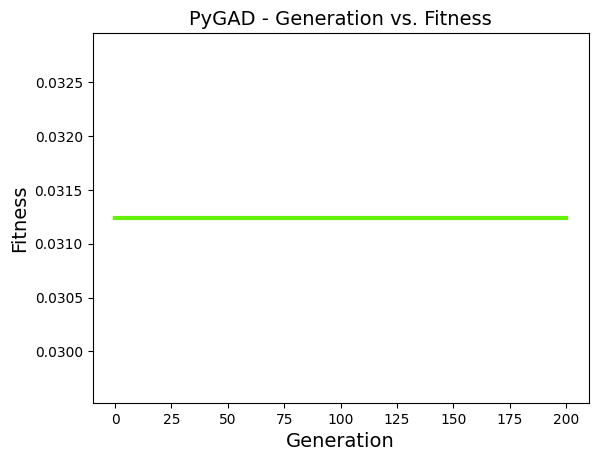

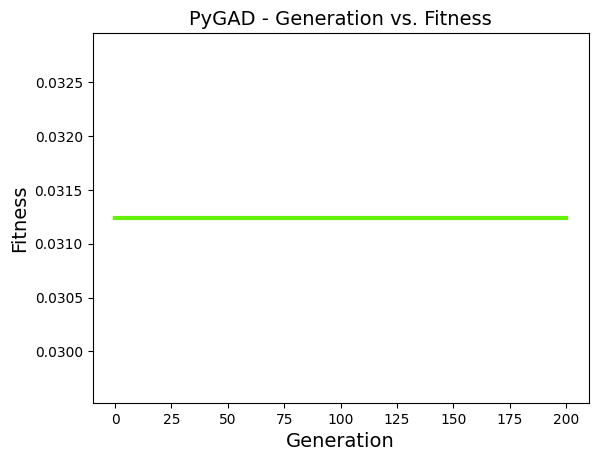

In [ ]:
# 1. Modelado de Datos
TASAS_OBRA = {
    0: (5, 4), 1: (7, 6), 2: (4, 5), 3: (6, 3), 4: (5, 4),
    5: (4, 3), 6: (3, 2), 7: (2, 3), 8: (4, 2), 9: (2, 2)
}
MAX_OPERARIOS = 10
NUM_TAREAS = len(TASAS_OBRA)

# 1. Cromosoma y Función de Fitness

def fitness_func(ga_instance, solution, solution_idx):
    # Calculo de tiempo de inicio y fin

    tiempos_inicio = np.round(solution).astype(int)
    tiempos_fin = [tiempos_inicio[i] + TASAS_OBRA[i][0] for i in range(NUM_TAREAS)]
    makespan = max(tiempos_fin)

# 2. Verificar la restricción de operarios por día
    penalizacion = 0
    # Recorremos cada día desde el inicio hasta el final de la obra
    for dia in range(makespan + 1):
        operarios_en_dia = 0
        for i in range(NUM_TAREAS):
            # Si la tarea i está activa en este día específico
            if tiempos_inicio[i] <= dia < tiempos_fin[i]:
                operarios_en_dia += TASAS_OBRA[i][1]

        # Si excedemos el límite de 10, aplicamos penalización
        if operarios_en_dia > MAX_OPERARIOS:
            penalizacion += 100 * (operarios_en_dia - MAX_OPERARIOS)

    # 3. Calcular Fitness
    # El fitness debe ser mayor cuanto mejor sea la solución.
    fitness = 1.0 / (makespan + penalizacion + 0.01)
    return fitness

ga_instance = pygad.GA(
    num_generations=200,
    num_parents_mating=10,
    fitness_func=fitness_func,
    sol_per_pop=50,
    num_genes=NUM_TAREAS,
    gene_type=int,

    # 1. Rango de valores para los genes
    init_range_low=0,
    init_range_high=40,

    # 2. Selección de padres (Cambió el nombre del parámetro)
    parent_selection_type="tournament",
    K_tournament=3,

    # 3. Cruce (Crossover)
    crossover_type="single_point",

    # 4. Mutación (Cambió el nombre del parámetro)
    mutation_type="random",
    mutation_percent_genes=15,
    random_mutation_min_val=0,
    random_mutation_max_val=40,

    # Mantener a los mejores
    keep_parents=2
)

# Ejecución
ga_instance.run()

# --- Análisis de Resultados ---
solution, solution_fitness, solution_idx = ga_instance.best_solution()

print("-" * 30)
print("RESULTADOS DE LA OPTIMIZACIÓN")
print("-" * 30)

tiempos_inicio = np.round(solution).astype(int)
tiempos_fin = [tiempos_inicio[i] + TASAS_OBRA[i][0] for i in range(NUM_TAREAS)]

for i in range(NUM_TAREAS):
    print(f"Tarea {i}: Inicia día {tiempos_inicio[i]}, Finaliza día {tiempos_fin[i]} (Operarios: {TASAS_OBRA[i][1]})")

print("-" * 30)
print(f"Tiempo total de obra (Makespan): {max(tiempos_fin)} días")
print(f"Fitness de la solución: {solution_fitness:.5f}")

# Graficar la evolución
ga_instance.plot_fitness()

## Si usan DEAP:

In [ ]:
import random
import numpy as np
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt